In [1]:
# 1. Imports --------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Optional: display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [5]:
# 1. Import libraries
import pandas as pd
import os

# 2. Check current working directory
print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in this directory:")
print(os.listdir())

# 3. Set the correct CSV file path
# If the CSV file is in the same folder as this notebook/script:
csv_path = "ChocoLush_Manchester.csv"

# If your file is inside a folder called 'data', use this instead:
# csv_path = "data/ChocoLush_Manchester.csv"

# 4. Load dataset safely
if os.path.exists(csv_path):
    data = pd.read_csv(csv_path)
    print("\nDataset Loaded Successfully ✅")
    print("\nFirst 5 Rows:")
    print(data.head())
    print("\nDataset Shape (rows, columns):")
    print(data.shape)
else:
    print(f"\n❌ File not found: {csv_path}")
    print("Check the file location and update the path.")

Current Working Directory:
/Users/adnanaltimeemy

Files in this directory:
['CostaCoffee.ipynb', 'Sycho.ipynb', 'obscure_scifi_books_dataset.csv', 'Hugin_Fm_Base_cleaned.csv', 'Untitled Folder', 'Heavenly_Desserts_Manchester_Sales.ipynb', 'world-universities_cleaned.csv', 'pret_menu.csv', 'asos_ocado_dataset.ipynb', 'decision_tree_intro.ipynb', 'CHECKOUT.ipynb', 'stress.csv', 'Dailyprices.ipynb', 'DSS.ipynb', 'Predicito.ipynb', ' penguin_random_house_sales_analysis.ipynb', 'degrees-that-pay-back.csv', 'Patrick.ipynb', 'iso.csv', 'hr-employee-attrition.csv', 'all_pivoted.csv', 'Compare.ipynb', 'Cod.ipynb', 'chiquito_taco_bell_uk_dataset.ipynb', 'michael_kors_sales_profit_demographics_analysis.ipynb', '.meteostat', 'Miscellaneous.ipynb', 'vw_vs_honda_comparison.csv', 'profit_dataset.csv', 'first_decision_tree.ipynb', 'fish_chips_data_insights.ipynb', 'wrestling_ppv_sales.ipynb', 'cybersecurity_books_sales_dataset.csv', 'Machine.Learning.Task.ipynb', 'DFA.ipynb', 'bmw_vs_toyota_sales_prof

In [6]:
# 3. Summary statistics and missingness ----------------------------------
print(data.info())
print(data.describe(include='all'))

# Count missing values by column
missing = data.isna().sum().sort_values(ascending=False)
print(missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BusinessID             22 non-null     object 
 1   BusinessName           22 non-null     object 
 2   Category               22 non-null     object 
 3   StreetAddress          22 non-null     object 
 4   City                   22 non-null     object 
 5   Region                 22 non-null     object 
 6   PostalCode             22 non-null     object 
 7   Country                22 non-null     object 
 8   Phone                  9 non-null      object 
 9   Email                  9 non-null      object 
 10  Website                9 non-null      object 
 11  OpeningHours           9 non-null      object 
 12  SeatingCapacity        9 non-null      object 
 13  AverageRating          1 non-null      float64
 14  TotalReviews           1 non-null      float64
 15  Signatur

In [9]:
# Clean column names first
data.columns = data.columns.str.strip()

# Drop rows only if the column exists
target_col = 'sales'

if target_col in data.columns:
    data = data.dropna(subset=[target_col])
else:
    print(f"{target_col} not found in columns")

# Fill numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].apply(lambda x: x.fillna(x.median()))

# Fill categorical columns
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
data[categorical_cols] = data[categorical_cols].fillna('Unknown')

data.info()

sales not found in columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BusinessID             22 non-null     object 
 1   BusinessName           22 non-null     object 
 2   Category               22 non-null     object 
 3   StreetAddress          22 non-null     object 
 4   City                   22 non-null     object 
 5   Region                 22 non-null     object 
 6   PostalCode             22 non-null     object 
 7   Country                22 non-null     object 
 8   Phone                  22 non-null     object 
 9   Email                  22 non-null     object 
 10  Website                22 non-null     object 
 11  OpeningHours           22 non-null     object 
 12  SeatingCapacity        22 non-null     object 
 13  AverageRating          22 non-null     float64
 14  TotalReviews           22 non-nul

In [12]:
print(data.columns.tolist())

['businessid', 'businessname', 'category', 'streetaddress', 'city', 'region', 'postalcode', 'country', 'phone', 'email', 'website', 'openinghours', 'seatingcapacity', 'averagerating', 'totalreviews', 'signatureitem', 'signatureitempricegbp', 'establishedyear', 'ownername', 'deliveryavailable', 'takeawayavailable', 'vegetarianoptions', 'veganoptions', 'glutenfreeoptions', 'lastinspectionscore', 'latitude', 'longitude']


In [13]:
# 6. Demographics overview
# Example demographic columns might include: age, income_level, household_size, postcode_area
demo_cols = ['age', 'income_level', 'household_size']  # adjust to match your dataset
for col in demo_cols:
    if col in data.columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(data[col], kde=False)
        plt.title(f'Distribution of {col}')
        plt.show()

In [14]:
# 7. Scatter plot of a demographic feature vs sales
# Choose one, e.g., 'income_level' if numeric
feature = 'income_level'  # change as applicable
if feature in data.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=data[feature], y=data['sales'])
    plt.title(f'{feature} vs Sales')
    plt.show()

/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


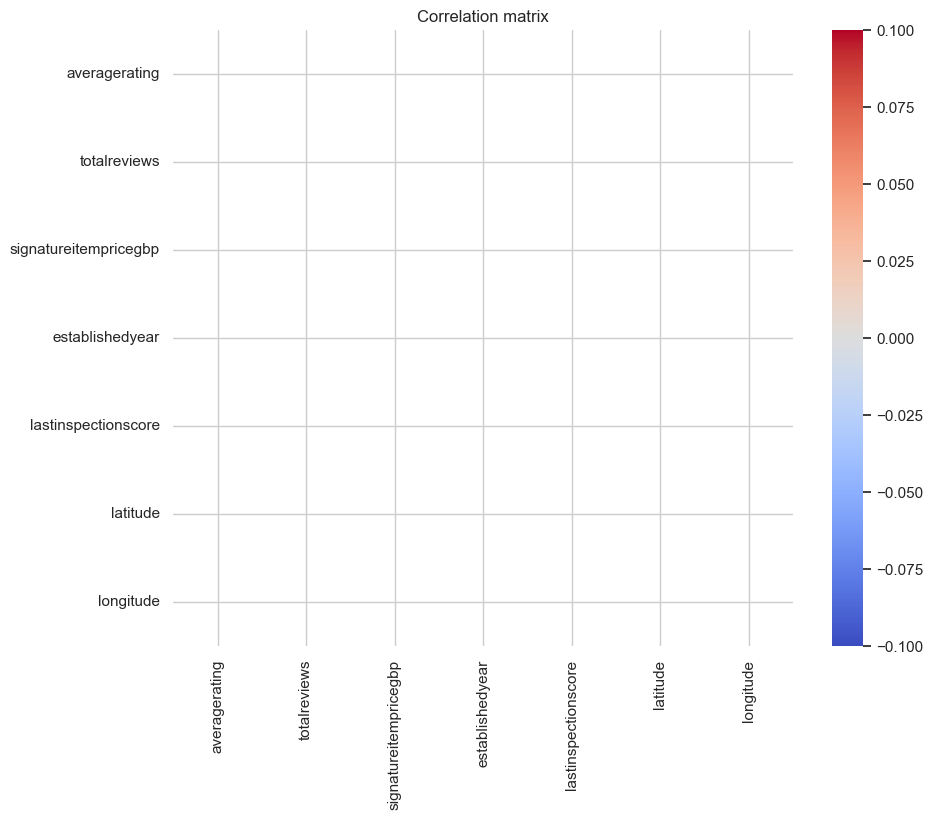

In [15]:
# 8. Correlation matrix for numeric columns
corr = data.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [18]:
print(data.columns)

Index(['businessid', 'businessname', 'category', 'streetaddress', 'city',
       'region', 'postalcode', 'country', 'phone', 'email', 'website',
       'openinghours', 'seatingcapacity', 'averagerating', 'totalreviews',
       'signatureitem', 'signatureitempricegbp', 'establishedyear',
       'ownername', 'deliveryavailable', 'takeawayavailable',
       'vegetarianoptions', 'veganoptions', 'glutenfreeoptions',
       'lastinspectionscore', 'latitude', 'longitude'],
      dtype='object')


In [19]:
data.columns = data.columns.str.strip().str.lower()
print(data.columns)

Index(['businessid', 'businessname', 'category', 'streetaddress', 'city',
       'region', 'postalcode', 'country', 'phone', 'email', 'website',
       'openinghours', 'seatingcapacity', 'averagerating', 'totalreviews',
       'signatureitem', 'signatureitempricegbp', 'establishedyear',
       'ownername', 'deliveryavailable', 'takeawayavailable',
       'vegetarianoptions', 'veganoptions', 'glutenfreeoptions',
       'lastinspectionscore', 'latitude', 'longitude'],
      dtype='object')


In [20]:
target_col = 'sales'

In [21]:
if target_col not in data.columns:
    print(f"Column '{target_col}' not found.")
    print("Available columns:", list(data.columns))
else:
    y = data[target_col]

Column 'sales' not found.
Available columns: ['businessid', 'businessname', 'category', 'streetaddress', 'city', 'region', 'postalcode', 'country', 'phone', 'email', 'website', 'openinghours', 'seatingcapacity', 'averagerating', 'totalreviews', 'signatureitem', 'signatureitempricegbp', 'establishedyear', 'ownername', 'deliveryavailable', 'takeawayavailable', 'vegetarianoptions', 'veganoptions', 'glutenfreeoptions', 'lastinspectionscore', 'latitude', 'longitude']


In [22]:
# 10. One-hot encode categorical variables if any exist in selected features
# Example: if 'postcode_area' is categorical
if 'postcode_area' in use_cols:
    X = pd.get_dummies(X, columns=['postcode_area'], drop_first=True)

In [28]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity', 'median_house_value'],
      dtype='object')


In [29]:
import os
print(os.listdir())

['CostaCoffee.ipynb', 'Sycho.ipynb', 'obscure_scifi_books_dataset.csv', 'Hugin_Fm_Base_cleaned.csv', 'Untitled Folder', 'Heavenly_Desserts_Manchester_Sales.ipynb', 'world-universities_cleaned.csv', 'pret_menu.csv', 'asos_ocado_dataset.ipynb', 'decision_tree_intro.ipynb', 'CHECKOUT.ipynb', 'stress.csv', 'Dailyprices.ipynb', 'DSS.ipynb', 'Predicito.ipynb', ' penguin_random_house_sales_analysis.ipynb', 'degrees-that-pay-back.csv', 'Patrick.ipynb', 'iso.csv', 'hr-employee-attrition.csv', 'all_pivoted.csv', 'Compare.ipynb', 'Cod.ipynb', 'chiquito_taco_bell_uk_dataset.ipynb', 'michael_kors_sales_profit_demographics_analysis.ipynb', '.meteostat', 'Miscellaneous.ipynb', 'vw_vs_honda_comparison.csv', 'profit_dataset.csv', 'first_decision_tree.ipynb', 'fish_chips_data_insights.ipynb', 'wrestling_ppv_sales.ipynb', 'cybersecurity_books_sales_dataset.csv', 'Machine.Learning.Task.ipynb', 'DFA.ipynb', 'bmw_vs_toyota_sales_profit_demographics_analysis.ipynb', 'presidents.csv', 'warrior_raw_flapjack_sa